In [1]:
# Add parent directory to Python path to import nc_csf module
import sys
from pathlib import Path

# Get the root directory (where nc_csf folder is located)
# Need to go up two levels: synthetic data -> non_cencoring -> root
root_dir = Path.cwd().parent.parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))
    
print(f"Added to path: {root_dir}")

Added to path: c:\Users\17414\OneDrive\桌面\USC\negavitve-control-proxies-causual-survival-forest


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

from nc_csf.evaluate_performance import run_experiment

Running experiments across proxy strength levels...
  Running: Corr(Z,U) = 0.1, sigma = 14.93...
  Running: Corr(Z,U) = 0.2, sigma = 7.35...
  Running: Corr(Z,U) = 0.3, sigma = 4.77...
  Running: Corr(Z,U) = 0.4, sigma = 3.44...
  Running: Corr(Z,U) = 0.5, sigma = 2.60...
  Running: Corr(Z,U) = 0.6, sigma = 2.00...
  Running: Corr(Z,U) = 0.7, sigma = 1.53...
  Running: Corr(Z,U) = 0.8, sigma = 1.12...
  Running: Corr(Z,U) = 0.9, sigma = 0.73...
Baseline with X only: 9 points
Baseline with X, Z, W: 9 points
NC-CSF: 9 points
Oracle: 9 points


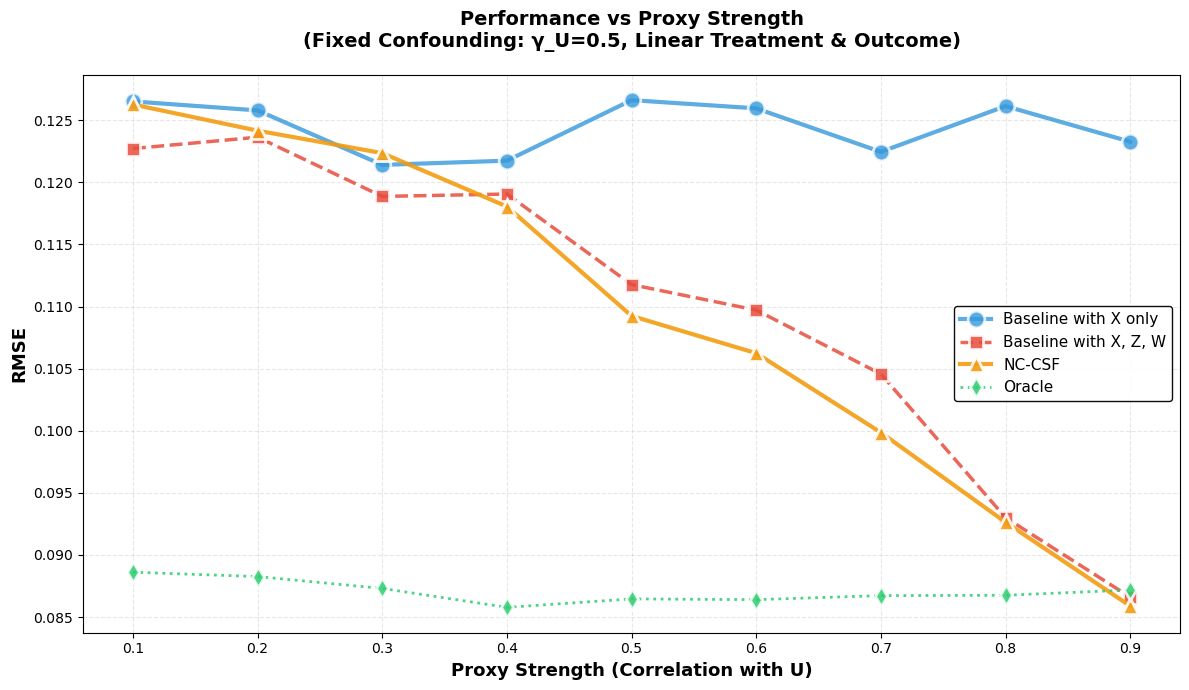

In [3]:
proxy_strengths = [
    {'corr': 0.1, 'sigma_z': 14.93, 'sigma_w': 14.93},
    {'corr': 0.2, 'sigma_z': 7.35, 'sigma_w': 7.35},
    {'corr': 0.3, 'sigma_z': 4.77, 'sigma_w': 4.77},
    {'corr': 0.4, 'sigma_z': 3.44, 'sigma_w': 3.44},
    {'corr': 0.5, 'sigma_z': 2.6, 'sigma_w': 2.6},
    {'corr': 0.6, 'sigma_z': 2.0, 'sigma_w': 2.0},
    {'corr': 0.7, 'sigma_z': 1.53, 'sigma_w': 1.53},
    {'corr': 0.8, 'sigma_z': 1.125, 'sigma_w': 1.125},
    {'corr': 0.9, 'sigma_z': 0.73, 'sigma_w': 0.73}
]

# Run experiments for each proxy strength level
print("Running experiments across proxy strength levels...")
all_results = []

for ps in proxy_strengths:
    print(f"  Running: Corr(Z,U) = {ps['corr']}, sigma = {ps['sigma_z']:.2f}...")
    results_df, cate_te, pred_baseline, pred_nccsf, pred_oracle = run_experiment(
        n=2000, p_x=10, seed=123,
        a_prevalence=0.5, gamma_u_in_a=0.5,
        k_t=1.5, lam_t=0.4, tau_log_hr=-0.5, beta_u_in_t=0.5,
        k_c=1.2, lam_c=1e6, beta_u_in_c=0.3, target_censor_rate=0, 
        max_censor_calib_iter=60, censor_lam_lo=1e-8, censor_lam_hi=1e6, admin_censor_time=None,
        aZ=1.5, sigma_z=ps['sigma_z'], aW=1.5, sigma_w=ps['sigma_w'],
        linear_treatment=True, linear_outcome=True
    )
    
    results_df['Proxy_Corr'] = ps['corr']
    all_results.append(results_df)

# Combine all results
combined_df = pd.concat(all_results, ignore_index=True)

# Create line plot with better visibility
fig, ax = plt.subplots(figsize=(12, 7))

# CORRECTED model names to match what run_experiment returns
models = ['Baseline with X only', 'Baseline with X, Z, W', 'NC-CSF', 'Oracle']
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
markers = ['o', 's', '^', 'd']
markersize = [12, 10, 12, 10]
linewidths = [3, 2.5, 3, 2]
linestyles = ['-', '--', '-', ':']
alphas = [0.8, 0.85, 0.9, 0.85]

for i, model in enumerate(models):
    model_data = combined_df[combined_df['Model'] == model].sort_values('Proxy_Corr')
    
    # Check if model exists in data
    if len(model_data) > 0:
        ax.plot(model_data['Proxy_Corr'], model_data['RMSE'], 
                label=model, color=colors[i], marker=markers[i], 
                markersize=markersize[i], linewidth=linewidths[i], 
                linestyle=linestyles[i], alpha=alphas[i],
                markeredgewidth=2, markeredgecolor='white')
        print(f"{model}: {len(model_data)} points")
    else:
        print(f"WARNING: {model} not found in results!")

ax.set_xlabel('Proxy Strength (Correlation with U)', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=13, fontweight='bold')
ax.set_title('Performance vs Proxy Strength\n(Fixed Confounding: γ_U=0.5, Linear Treatment & Outcome)', 
             fontsize=14, fontweight='bold', pad=20)

ax.legend(loc='best', fontsize=11, framealpha=0.95, edgecolor='black', fancybox=True)

ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Running experiments across proxy strength levels...
  Running: Corr(Z,U) = 0.1, sigma = 14.93...
  Running: Corr(Z,U) = 0.2, sigma = 7.35...
  Running: Corr(Z,U) = 0.3, sigma = 4.77...
  Running: Corr(Z,U) = 0.4, sigma = 3.44...
  Running: Corr(Z,U) = 0.5, sigma = 2.60...
  Running: Corr(Z,U) = 0.6, sigma = 2.00...
  Running: Corr(Z,U) = 0.7, sigma = 1.53...
  Running: Corr(Z,U) = 0.8, sigma = 1.12...
  Running: Corr(Z,U) = 0.9, sigma = 0.73...
Baseline with X only: 9 points
Baseline with X, Z, W: 9 points
NC-CSF: 9 points
Oracle: 9 points


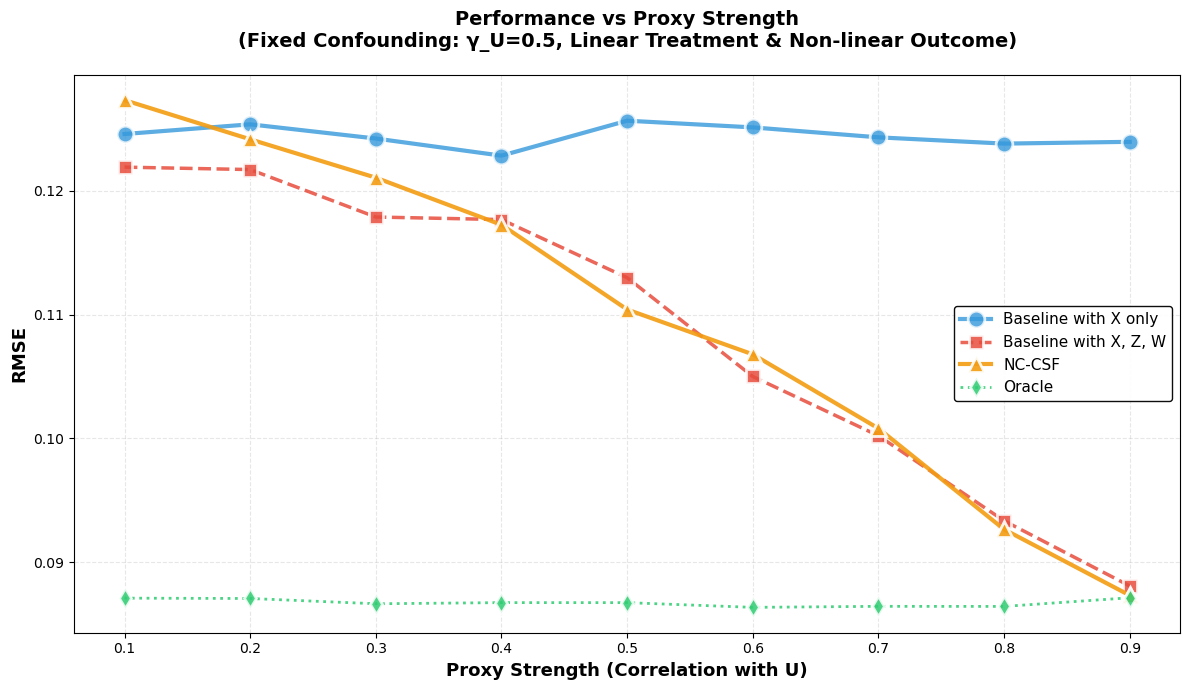

In [4]:
# Run experiments for each proxy strength level
print("Running experiments across proxy strength levels...")
all_results = []

for ps in proxy_strengths:
    print(f"  Running: Corr(Z,U) = {ps['corr']}, sigma = {ps['sigma_z']:.2f}...")
    results_df, cate_te, pred_baseline, pred_nccsf, pred_oracle = run_experiment(
        n=2000, p_x=10, seed=123,
        a_prevalence=0.5, gamma_u_in_a=0.5,
        k_t=1.5, lam_t=0.4, tau_log_hr=-0.5, beta_u_in_t=0.5,
        k_c=1.2, lam_c=1e6, beta_u_in_c=0.3, target_censor_rate=0, 
        max_censor_calib_iter=60, censor_lam_lo=1e-8, censor_lam_hi=1e6, admin_censor_time=None,
        aZ=1.5, sigma_z=ps['sigma_z'], aW=1.5, sigma_w=ps['sigma_w'],
        linear_treatment=True, linear_outcome=False
    )
    
    results_df['Proxy_Corr'] = ps['corr']
    all_results.append(results_df)

# Combine all results
combined_df = pd.concat(all_results, ignore_index=True)

# Create line plot with better visibility
fig, ax = plt.subplots(figsize=(12, 7))

# CORRECTED model names to match what run_experiment returns
models = ['Baseline with X only', 'Baseline with X, Z, W', 'NC-CSF', 'Oracle']
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
markers = ['o', 's', '^', 'd']
markersize = [12, 10, 12, 10]
linewidths = [3, 2.5, 3, 2]
linestyles = ['-', '--', '-', ':']
alphas = [0.8, 0.85, 0.9, 0.85]

for i, model in enumerate(models):
    model_data = combined_df[combined_df['Model'] == model].sort_values('Proxy_Corr')
    
    # Check if model exists in data
    if len(model_data) > 0:
        ax.plot(model_data['Proxy_Corr'], model_data['RMSE'], 
                label=model, color=colors[i], marker=markers[i], 
                markersize=markersize[i], linewidth=linewidths[i], 
                linestyle=linestyles[i], alpha=alphas[i],
                markeredgewidth=2, markeredgecolor='white')
        print(f"{model}: {len(model_data)} points")
    else:
        print(f"WARNING: {model} not found in results!")

ax.set_xlabel('Proxy Strength (Correlation with U)', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=13, fontweight='bold')
ax.set_title('Performance vs Proxy Strength\n(Fixed Confounding: γ_U=0.5, Linear Treatment & Non-linear Outcome)', 
             fontsize=14, fontweight='bold', pad=20)

ax.legend(loc='best', fontsize=11, framealpha=0.95, edgecolor='black', fancybox=True)

ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Running experiments across proxy strength levels...
  Running: Corr(Z,U) = 0.1, sigma = 14.93...
  Running: Corr(Z,U) = 0.2, sigma = 7.35...
  Running: Corr(Z,U) = 0.3, sigma = 4.77...
  Running: Corr(Z,U) = 0.4, sigma = 3.44...
  Running: Corr(Z,U) = 0.5, sigma = 2.60...
  Running: Corr(Z,U) = 0.6, sigma = 2.00...
  Running: Corr(Z,U) = 0.7, sigma = 1.53...
  Running: Corr(Z,U) = 0.8, sigma = 1.12...
  Running: Corr(Z,U) = 0.9, sigma = 0.73...
Baseline with X only: 9 points
Baseline with X, Z, W: 9 points
NC-CSF: 9 points
Oracle: 9 points


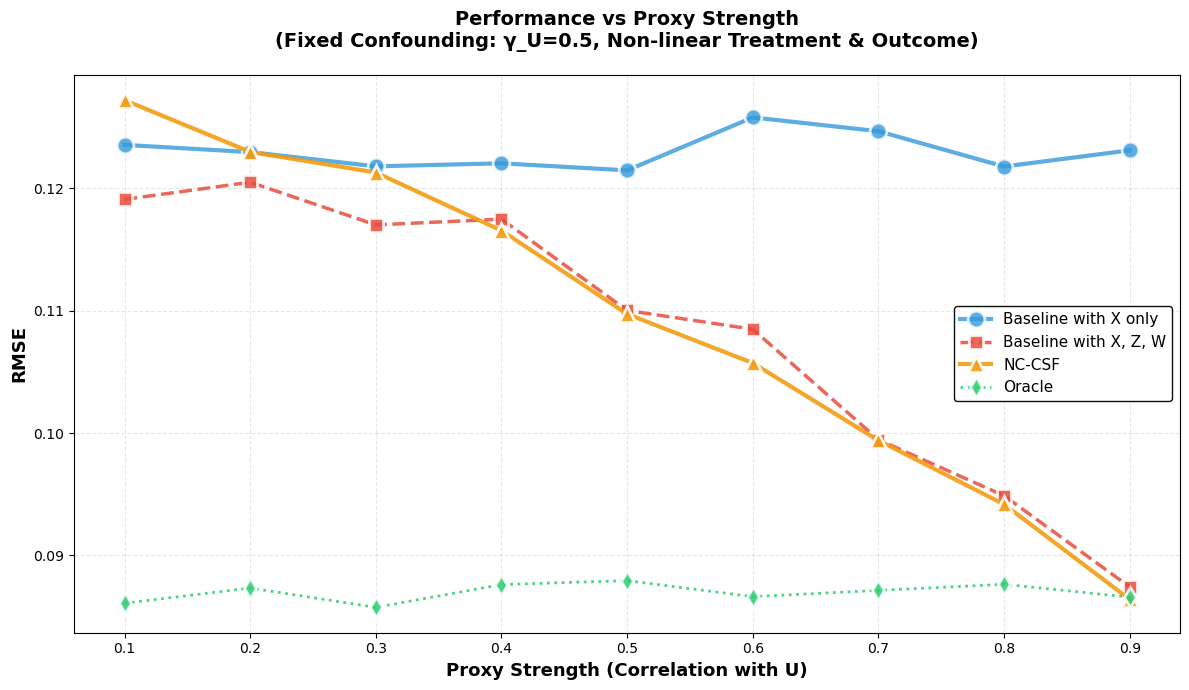

In [5]:
# Run experiments for each proxy strength level
print("Running experiments across proxy strength levels...")
all_results = []

for ps in proxy_strengths:
    print(f"  Running: Corr(Z,U) = {ps['corr']}, sigma = {ps['sigma_z']:.2f}...")
    results_df, cate_te, pred_baseline, pred_nccsf, pred_oracle = run_experiment(
        n=2000, p_x=10, seed=123,
        a_prevalence=0.5, gamma_u_in_a=0.5,
        k_t=1.5, lam_t=0.4, tau_log_hr=-0.5, beta_u_in_t=0.5,
        k_c=1.2, lam_c=1e6, beta_u_in_c=0.3, target_censor_rate=0, 
        max_censor_calib_iter=60, censor_lam_lo=1e-8, censor_lam_hi=1e6, admin_censor_time=None,
        aZ=1.5, sigma_z=ps['sigma_z'], aW=1.5, sigma_w=ps['sigma_w'],
        linear_treatment=False, linear_outcome=False
    )
    
    results_df['Proxy_Corr'] = ps['corr']
    all_results.append(results_df)

# Combine all results
combined_df = pd.concat(all_results, ignore_index=True)

# Create line plot with better visibility
fig, ax = plt.subplots(figsize=(12, 7))

# CORRECTED model names to match what run_experiment returns
models = ['Baseline with X only', 'Baseline with X, Z, W', 'NC-CSF', 'Oracle']
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
markers = ['o', 's', '^', 'd']
markersize = [12, 10, 12, 10]
linewidths = [3, 2.5, 3, 2]
linestyles = ['-', '--', '-', ':']
alphas = [0.8, 0.85, 0.9, 0.85]

for i, model in enumerate(models):
    model_data = combined_df[combined_df['Model'] == model].sort_values('Proxy_Corr')
    
    # Check if model exists in data
    if len(model_data) > 0:
        ax.plot(model_data['Proxy_Corr'], model_data['RMSE'], 
                label=model, color=colors[i], marker=markers[i], 
                markersize=markersize[i], linewidth=linewidths[i], 
                linestyle=linestyles[i], alpha=alphas[i],
                markeredgewidth=2, markeredgecolor='white')
        print(f"{model}: {len(model_data)} points")
    else:
        print(f"WARNING: {model} not found in results!")

ax.set_xlabel('Proxy Strength (Correlation with U)', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=13, fontweight='bold')
ax.set_title('Performance vs Proxy Strength\n(Fixed Confounding: γ_U=0.5, Non-linear Treatment & Outcome)', 
             fontsize=14, fontweight='bold', pad=20)

ax.legend(loc='best', fontsize=11, framealpha=0.95, edgecolor='black', fancybox=True)

ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Running experiments across confounding strength levels...
  Running: none confounding (γ_U=0.0, β_U=0.0)...
  Running: weak confounding (γ_U=0.1, β_U=0.1)...
  Running: weak confounding (γ_U=0.2, β_U=0.2)...
  Running: weak confounding (γ_U=0.3, β_U=0.3)...
  Running: weak confounding (γ_U=0.4, β_U=0.4)...
  Running: moderate confounding (γ_U=0.5, β_U=0.5)...
  Running: moderate confounding (γ_U=0.6, β_U=0.6)...
  Running: moderate confounding (γ_U=0.7, β_U=0.7)...
  Running: strong confounding (γ_U=0.9, β_U=0.9)...
  Running: strong confounding (γ_U=1.1, β_U=1.1)...
  Running: strong confounding (γ_U=1.2, β_U=1.2)...
  Running: extreme confounding (γ_U=1.4, β_U=1.4)...
  Running: strong confounding (γ_U=1.6, β_U=1.6)...
Baseline with X only: 13 points
Baseline with X, Z, W: 13 points
NC-CSF: 13 points
Oracle: 13 points


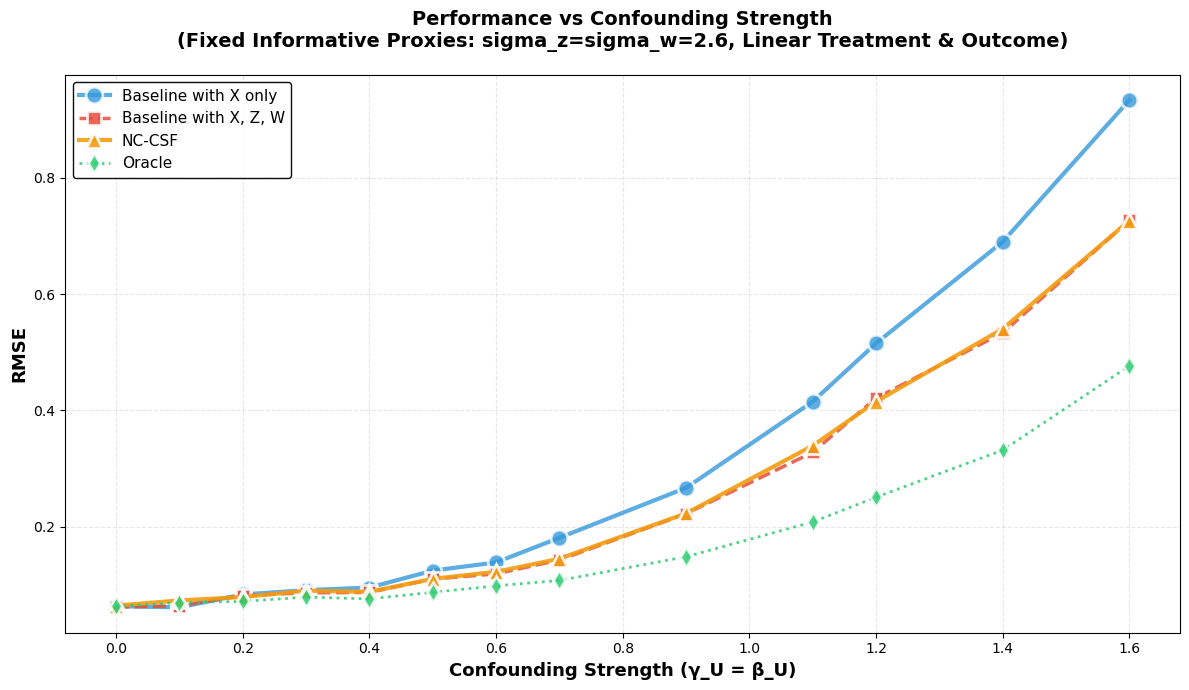

In [ ]:
confounding_strengths = [
    {'level': 'none', 'gamma_u_in_a': 0.0, 'beta_u_in_t': 0.0},
    {'level': 'weak', 'gamma_u_in_a': 0.1, 'beta_u_in_t': 0.1},
    {'level': 'weak', 'gamma_u_in_a': 0.2, 'beta_u_in_t': 0.2},
    {'level': 'weak', 'gamma_u_in_a': 0.3, 'beta_u_in_t': 0.3},
    {'level': 'weak', 'gamma_u_in_a': 0.4, 'beta_u_in_t': 0.4},
    {'level': 'moderate', 'gamma_u_in_a': 0.5, 'beta_u_in_t': 0.5},
    {'level': 'moderate', 'gamma_u_in_a': 0.6, 'beta_u_in_t': 0.6},
    {'level': 'moderate', 'gamma_u_in_a': 0.7, 'beta_u_in_t': 0.7},
    {'level': 'strong', 'gamma_u_in_a': 0.9, 'beta_u_in_t': 0.9},
    {'level': 'strong', 'gamma_u_in_a': 1.1, 'beta_u_in_t': 1.1},
    {'level': 'strong', 'gamma_u_in_a': 1.2, 'beta_u_in_t': 1.2},
    {'level': 'extreme', 'gamma_u_in_a': 1.4, 'beta_u_in_t': 1.4},
    {'level': 'extreme', 'gamma_u_in_a': 1.6, 'beta_u_in_t': 1.6}
]

# Run experiments for each confounding strength level
print("Running experiments across confounding strength levels...")
all_results = []

for cs in confounding_strengths:
    print(f"  Running: {cs['level']} confounding (γ_U={cs['gamma_u_in_a']}, β_U={cs['beta_u_in_t']})...")
    results_df, cate_te, pred_baseline, pred_nccsf, pred_oracle = run_experiment(
        n=2000, p_x=10, seed=123,
        a_prevalence=0.5, gamma_u_in_a=cs['gamma_u_in_a'],
        k_t=1.5, lam_t=0.4, tau_log_hr=-0.5, beta_u_in_t=cs['beta_u_in_t'],
        k_c=1.2, lam_c=1e6, beta_u_in_c=0.3, target_censor_rate=0, 
        max_censor_calib_iter=60, censor_lam_lo=1e-8, censor_lam_hi=1e6, admin_censor_time=None,
        aZ=1.5, sigma_z=2.6, aW=1.5, sigma_w=2.6,
        linear_treatment=True, linear_outcome=True
    )
    
    results_df['Confounding_Strength'] = cs['gamma_u_in_a']
    results_df['Confounding_Level'] = cs['level']
    all_results.append(results_df)

# Combine all results
combined_df = pd.concat(all_results, ignore_index=True)

# Create line plot with better visibility
fig, ax = plt.subplots(figsize=(12, 7))

# Model names matching run_experiment output
models = ['Baseline with X only', 'Baseline with X, Z, W', 'NC-CSF', 'Oracle']
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
markers = ['o', 's', '^', 'd']
markersize = [12, 10, 12, 10]
linewidths = [3, 2.5, 3, 2]
linestyles = ['-', '--', '-', ':']
alphas = [0.8, 0.85, 0.9, 0.85]

for i, model in enumerate(models):
    model_data = combined_df[combined_df['Model'] == model].sort_values('Confounding_Strength')
    
    # Check if model exists in data
    if len(model_data) > 0:
        ax.plot(model_data['Confounding_Strength'], model_data['RMSE'], 
                label=model, color=colors[i], marker=markers[i], 
                markersize=markersize[i], linewidth=linewidths[i], 
                linestyle=linestyles[i], alpha=alphas[i],
                markeredgewidth=2, markeredgecolor='white')
        print(f"{model}: {len(model_data)} points")
    else:
        print(f"WARNING: {model} not found in results!")

ax.set_xlabel('Confounding Strength (γ_U = β_U)', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=13, fontweight='bold')
ax.set_title('Performance vs Confounding Strength\n(Fixed Informative Proxies: sigma_z=sigma_w=2.6, Linear Treatment & Outcome)', 
             fontsize=14, fontweight='bold', pad=20)

ax.legend(loc='best', fontsize=11, framealpha=0.95, edgecolor='black', fancybox=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Running experiments across confounding strength levels...
  Running: none confounding (γ_U=0.0, β_U=0.0)...
  Running: weak confounding (γ_U=0.1, β_U=0.1)...
  Running: weak confounding (γ_U=0.2, β_U=0.2)...
  Running: weak confounding (γ_U=0.3, β_U=0.3)...
  Running: weak confounding (γ_U=0.4, β_U=0.4)...
  Running: moderate confounding (γ_U=0.5, β_U=0.5)...
  Running: moderate confounding (γ_U=0.6, β_U=0.6)...
  Running: moderate confounding (γ_U=0.7, β_U=0.7)...
  Running: strong confounding (γ_U=0.9, β_U=0.9)...
  Running: strong confounding (γ_U=1.1, β_U=1.1)...
  Running: strong confounding (γ_U=1.2, β_U=1.2)...
  Running: extreme confounding (γ_U=1.4, β_U=1.4)...
  Running: strong confounding (γ_U=1.6, β_U=1.6)...
Baseline with X only: 13 points
Baseline with X, Z, W: 13 points
NC-CSF: 13 points
Oracle: 13 points


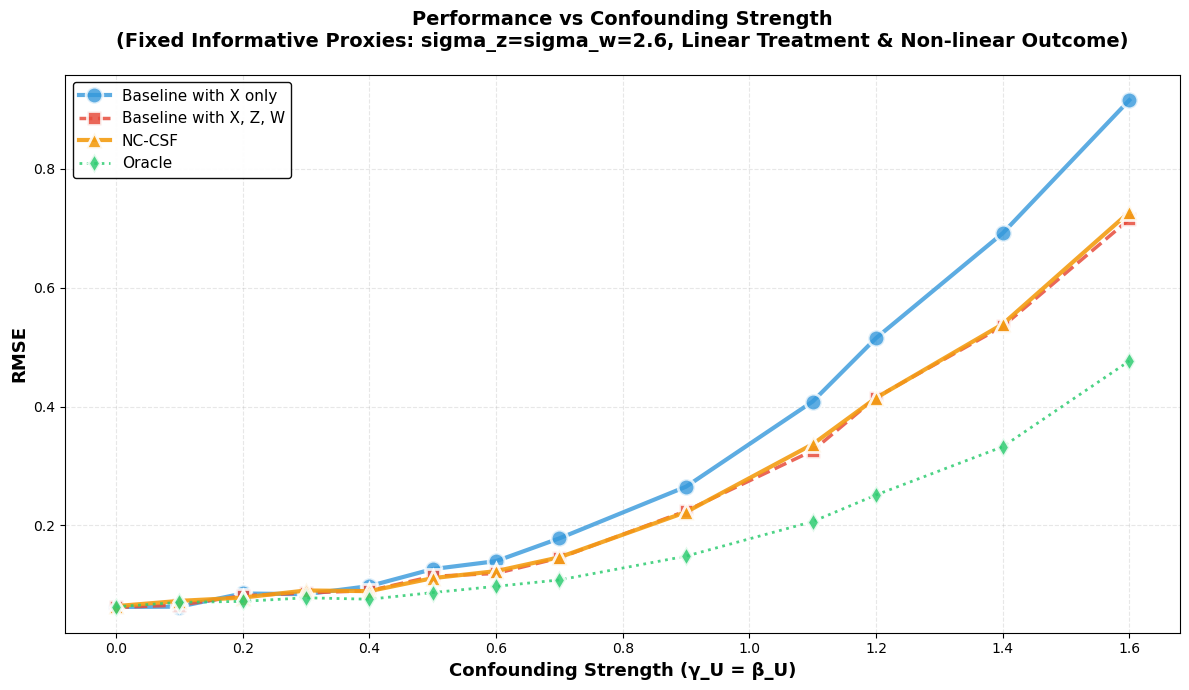

In [7]:
# Run experiments for each confounding strength level
print("Running experiments across confounding strength levels...")
all_results = []

for cs in confounding_strengths:
    print(f"  Running: {cs['level']} confounding (γ_U={cs['gamma_u_in_a']}, β_U={cs['beta_u_in_t']})...")
    results_df, cate_te, pred_baseline, pred_nccsf, pred_oracle = run_experiment(
        n=2000, p_x=10, seed=123,
        a_prevalence=0.5, gamma_u_in_a=cs['gamma_u_in_a'],
        k_t=1.5, lam_t=0.4, tau_log_hr=-0.5, beta_u_in_t=cs['beta_u_in_t'],
        k_c=1.2, lam_c=1e6, beta_u_in_c=0.3, target_censor_rate=0, 
        max_censor_calib_iter=60, censor_lam_lo=1e-8, censor_lam_hi=1e6, admin_censor_time=None,
        aZ=1.5, sigma_z=2.6, aW=1.5, sigma_w=2.6,
        linear_treatment=True, linear_outcome=False
    )
    
    results_df['Confounding_Strength'] = cs['gamma_u_in_a']
    results_df['Confounding_Level'] = cs['level']
    all_results.append(results_df)

# Combine all results
combined_df = pd.concat(all_results, ignore_index=True)

# Create line plot with better visibility
fig, ax = plt.subplots(figsize=(12, 7))

# Model names matching run_experiment output
models = ['Baseline with X only', 'Baseline with X, Z, W', 'NC-CSF', 'Oracle']
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
markers = ['o', 's', '^', 'd']
markersize = [12, 10, 12, 10]
linewidths = [3, 2.5, 3, 2]
linestyles = ['-', '--', '-', ':']
alphas = [0.8, 0.85, 0.9, 0.85]

for i, model in enumerate(models):
    model_data = combined_df[combined_df['Model'] == model].sort_values('Confounding_Strength')
    
    # Check if model exists in data
    if len(model_data) > 0:
        ax.plot(model_data['Confounding_Strength'], model_data['RMSE'], 
                label=model, color=colors[i], marker=markers[i], 
                markersize=markersize[i], linewidth=linewidths[i], 
                linestyle=linestyles[i], alpha=alphas[i],
                markeredgewidth=2, markeredgecolor='white')
        print(f"{model}: {len(model_data)} points")
    else:
        print(f"WARNING: {model} not found in results!")

ax.set_xlabel('Confounding Strength (γ_U = β_U)', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=13, fontweight='bold')
ax.set_title('Performance vs Confounding Strength\n(Fixed Informative Proxies: sigma_z=sigma_w=2.6, Linear Treatment & Non-linear Outcome)', 
             fontsize=14, fontweight='bold', pad=20)

ax.legend(loc='best', fontsize=11, framealpha=0.95, edgecolor='black', fancybox=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

Running experiments across confounding strength levels...
  Running: none confounding (γ_U=0.0, β_U=0.0)...
  Running: weak confounding (γ_U=0.1, β_U=0.1)...
  Running: weak confounding (γ_U=0.2, β_U=0.2)...
  Running: weak confounding (γ_U=0.3, β_U=0.3)...
  Running: weak confounding (γ_U=0.4, β_U=0.4)...
  Running: moderate confounding (γ_U=0.5, β_U=0.5)...
  Running: moderate confounding (γ_U=0.6, β_U=0.6)...
  Running: moderate confounding (γ_U=0.7, β_U=0.7)...
  Running: strong confounding (γ_U=0.9, β_U=0.9)...
  Running: strong confounding (γ_U=1.1, β_U=1.1)...
  Running: strong confounding (γ_U=1.2, β_U=1.2)...
  Running: extreme confounding (γ_U=1.4, β_U=1.4)...
  Running: strong confounding (γ_U=1.6, β_U=1.6)...
Baseline with X only: 13 points
Baseline with X, Z, W: 13 points
NC-CSF: 13 points
Oracle: 13 points


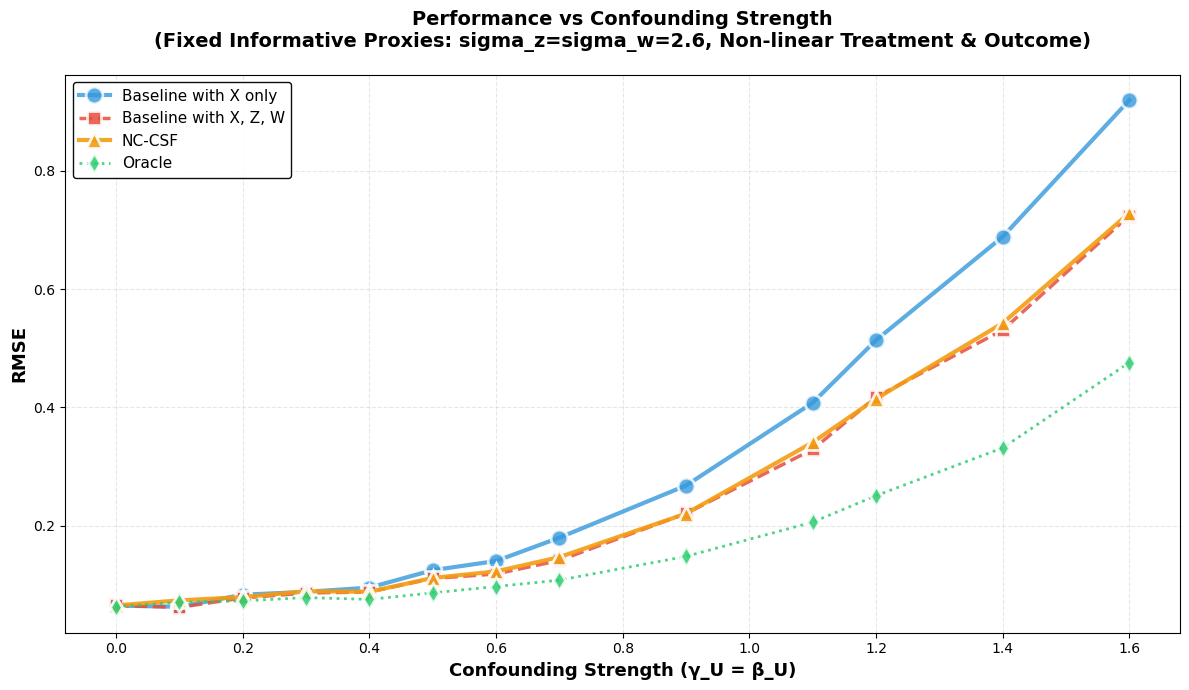

In [8]:
# Run experiments for each confounding strength level
print("Running experiments across confounding strength levels...")
all_results = []

for cs in confounding_strengths:
    print(f"  Running: {cs['level']} confounding (γ_U={cs['gamma_u_in_a']}, β_U={cs['beta_u_in_t']})...")
    results_df, cate_te, pred_baseline, pred_nccsf, pred_oracle = run_experiment(
        n=2000, p_x=10, seed=123,
        a_prevalence=0.5, gamma_u_in_a=cs['gamma_u_in_a'],
        k_t=1.5, lam_t=0.4, tau_log_hr=-0.5, beta_u_in_t=cs['beta_u_in_t'],
        k_c=1.2, lam_c=1e6, beta_u_in_c=0.3, target_censor_rate=0, 
        max_censor_calib_iter=60, censor_lam_lo=1e-8, censor_lam_hi=1e6, admin_censor_time=None,
        aZ=1.5, sigma_z=2.6, aW=1.5, sigma_w=2.6,
        linear_treatment=False, linear_outcome=False
    )
    
    results_df['Confounding_Strength'] = cs['gamma_u_in_a']
    results_df['Confounding_Level'] = cs['level']
    all_results.append(results_df)

# Combine all results
combined_df = pd.concat(all_results, ignore_index=True)

# Create line plot with better visibility
fig, ax = plt.subplots(figsize=(12, 7))

# Model names matching run_experiment output
models = ['Baseline with X only', 'Baseline with X, Z, W', 'NC-CSF', 'Oracle']
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']
markers = ['o', 's', '^', 'd']
markersize = [12, 10, 12, 10]
linewidths = [3, 2.5, 3, 2]
linestyles = ['-', '--', '-', ':']
alphas = [0.8, 0.85, 0.9, 0.85]

for i, model in enumerate(models):
    model_data = combined_df[combined_df['Model'] == model].sort_values('Confounding_Strength')
    
    # Check if model exists in data
    if len(model_data) > 0:
        ax.plot(model_data['Confounding_Strength'], model_data['RMSE'], 
                label=model, color=colors[i], marker=markers[i], 
                markersize=markersize[i], linewidth=linewidths[i], 
                linestyle=linestyles[i], alpha=alphas[i],
                markeredgewidth=2, markeredgecolor='white')
        print(f"{model}: {len(model_data)} points")
    else:
        print(f"WARNING: {model} not found in results!")

ax.set_xlabel('Confounding Strength (γ_U = β_U)', fontsize=13, fontweight='bold')
ax.set_ylabel('RMSE', fontsize=13, fontweight='bold')
ax.set_title('Performance vs Confounding Strength\n(Fixed Informative Proxies: sigma_z=sigma_w=2.6, Non-linear Treatment & Outcome)', 
             fontsize=14, fontweight='bold', pad=20)

ax.legend(loc='best', fontsize=11, framealpha=0.95, edgecolor='black', fancybox=True)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [ ]:
# Linear in treatment and outcome - Experiment 1
# Informative proxies & strong confounding & harmful large treatment effect
exp1_linear_linear = [
    {'Model': 'Baseline with X only', 'RMSE': 0.496308, 'MAE': 0.339909, 'Bias': -0.339720, 'Pearson r': -0.168692, 'Spearman r': -0.094195, 'Rel RMSE': 1.415968, 'Slope': -0.023288},
    {'Model': 'Baseline with X, Z, W', 'RMSE': 0.391892, 'MAE': 0.213205, 'Bias': -0.189599, 'Pearson r': 0.208743, 'Spearman r': 0.337106, 'Rel RMSE': 1.118068, 'Slope': 0.036833},
    {'Model': 'NC-CSF', 'RMSE': 0.378904, 'MAE': 0.205822, 'Bias': -0.142946, 'Pearson r': 0.063929, 'Spearman r': 0.159444, 'Rel RMSE': 1.081014, 'Slope': 0.009191},
    {'Model': 'Oracle', 'RMSE': 0.332135, 'MAE': 0.209625, 'Bias': 0.002292, 'Pearson r': 0.353284, 'Spearman r': 0.440229, 'Rel RMSE': 0.947581, 'Slope': 0.071658}
]

# Linear in treatment and outcome - Experiment 2
# Informative proxies & weak confounding & beneficial small treatment effect
exp2_linear_linear = [
    {'Model': 'Baseline with X only', 'RMSE': 0.040220, 'MAE': 0.033240, 'Bias': -0.027184, 'Pearson r': 0.748104, 'Spearman r': 0.722730, 'Rel RMSE': 0.933914, 'Slope': 0.696913},
    {'Model': 'Baseline with X, Z, W', 'RMSE': 0.040213, 'MAE': 0.032432, 'Bias': -0.025144, 'Pearson r': 0.726446, 'Spearman r': 0.692692, 'Rel RMSE': 0.933745, 'Slope': 0.704245},
    {'Model': 'NC-CSF', 'RMSE': 0.033560, 'MAE': 0.025973, 'Bias': -0.010052, 'Pearson r': 0.687433, 'Spearman r': 0.601285, 'Rel RMSE': 0.779270, 'Slope': 0.582397},
    {'Model': 'Oracle', 'RMSE': 0.033877, 'MAE': 0.025445, 'Bias': -0.004949, 'Pearson r': 0.644076, 'Spearman r': 0.549941, 'Rel RMSE': 0.786629, 'Slope': 0.507196}
]

# Linear in treatment and outcome - Experiment 3
# Non informative proxies & strong confounding & beneficial moderate treatment effect
exp3_linear_linear = [
    {'Model': 'Baseline with X only', 'RMSE': 0.282963, 'MAE': 0.253840, 'Bias': -0.231789, 'Pearson r': 0.423918, 'Spearman r': 0.510157, 'Rel RMSE': 1.693566, 'Slope': 0.328786},
    {'Model': 'Baseline with X, Z, W', 'RMSE': 0.168043, 'MAE': 0.132859, 'Bias': -0.094843, 'Pearson r': 0.563490, 'Spearman r': 0.723323, 'Rel RMSE': 1.005756, 'Slope': 0.364375},
    {'Model': 'NC-CSF', 'RMSE': 0.164674, 'MAE': 0.119518, 'Bias': -0.051297, 'Pearson r': 0.374249, 'Spearman r': 0.447369, 'Rel RMSE': 0.985593, 'Slope': 0.189266},
    {'Model': 'Oracle', 'RMSE': 0.156690, 'MAE': 0.093355, 'Bias': 0.011802, 'Pearson r': 0.354808, 'Spearman r': 0.411814, 'Rel RMSE': 0.937808, 'Slope': 0.119011}
]

# Linear in treatment and outcome - Experiment 4
# Non informative proxies & weak confounding & near null treatment effect
exp4_linear_linear = [
    {'Model': 'Baseline with X only', 'RMSE': 0.039114, 'MAE': 0.029207, 'Bias': -0.026392, 'Pearson r': 0.655704, 'Spearman r': 0.565168, 'Rel RMSE': 1.813530, 'Slope': 1.155425},
    {'Model': 'Baseline with X, Z, W', 'RMSE': 0.033115, 'MAE': 0.023517, 'Bias': -0.019089, 'Pearson r': 0.664313, 'Spearman r': 0.558563, 'Rel RMSE': 1.535366, 'Slope': 1.111439},
    {'Model': 'NC-CSF', 'RMSE': 0.024799, 'MAE': 0.018648, 'Bias': -0.002665, 'Pearson r': 0.494575, 'Spearman r': 0.294357, 'Rel RMSE': 1.149784, 'Slope': 0.612244},
    {'Model': 'Oracle', 'RMSE': 0.024334, 'MAE': 0.017809, 'Bias': 0.002803, 'Pearson r': 0.480253, 'Spearman r': 0.268349, 'Rel RMSE': 1.128239, 'Slope': 0.566054}
]

# Non linear in only outcome - Experiment 5
# Informative proxies & strong confounding & harmful large treatment effect
exp5_linear_nonlinear = [
    {'Model': 'Baseline with X only', 'RMSE': 0.496513, 'MAE': 0.342175, 'Bias': -0.342056, 'Pearson r': -0.160847, 'Spearman r': -0.123777, 'Rel RMSE': 1.424314, 'Slope': -0.022857},
    {'Model': 'Baseline with X, Z, W', 'RMSE': 0.394348, 'MAE': 0.212685, 'Bias': -0.194942, 'Pearson r': 0.186760, 'Spearman r': 0.256327, 'Rel RMSE': 1.131241, 'Slope': 0.026841},
    {'Model': 'NC-CSF', 'RMSE': 0.381224, 'MAE': 0.203886, 'Bias': -0.150949, 'Pearson r': 0.030875, 'Spearman r': 0.086503, 'Rel RMSE': 1.093591, 'Slope': 0.003948},
    {'Model': 'Oracle', 'RMSE': 0.332703, 'MAE': 0.203359, 'Bias': -0.007469, 'Pearson r': 0.335242, 'Spearman r': 0.428823, 'Rel RMSE': 0.954402, 'Slope': 0.061796}
]

# Non linear in only outcome - Experiment 6
# Informative proxies & weak confounding & beneficial small treatment effect
exp6_linear_nonlinear = [
    {'Model': 'Baseline with X only', 'RMSE': 0.042587, 'MAE': 0.034949, 'Bias': -0.027328, 'Pearson r': 0.754424, 'Spearman r': 0.751251, 'Rel RMSE': 0.863578, 'Slope': 0.636370},
    {'Model': 'Baseline with X, Z, W', 'RMSE': 0.039657, 'MAE': 0.032023, 'Bias': -0.021836, 'Pearson r': 0.743314, 'Spearman r': 0.752719, 'Rel RMSE': 0.804163, 'Slope': 0.594580},
    {'Model': 'NC-CSF', 'RMSE': 0.038894, 'MAE': 0.029488, 'Bias': -0.009509, 'Pearson r': 0.646470, 'Spearman r': 0.616435, 'Rel RMSE': 0.788676, 'Slope': 0.452140},
    {'Model': 'Oracle', 'RMSE': 0.039178, 'MAE': 0.028647, 'Bias': -0.002817, 'Pearson r': 0.610033, 'Spearman r': 0.545412, 'Rel RMSE': 0.794436, 'Slope': 0.373804}
]

# Non linear in only outcome - Experiment 7
# Non informative proxies & strong confounding & beneficial moderate treatment effect
exp7_linear_nonlinear = [
    {'Model': 'Baseline with X only', 'RMSE': 0.276802, 'MAE': 0.251208, 'Bias': -0.227190, 'Pearson r': 0.403639, 'Spearman r': 0.492608, 'Rel RMSE': 1.665769, 'Slope': 0.268712},
    {'Model': 'Baseline with X, Z, W', 'RMSE': 0.163370, 'MAE': 0.129017, 'Bias': -0.092487, 'Pearson r': 0.586671, 'Spearman r': 0.734200, 'Rel RMSE': 0.983149, 'Slope': 0.362865},
    {'Model': 'NC-CSF', 'RMSE': 0.162536, 'MAE': 0.116540, 'Bias': -0.047674, 'Pearson r': 0.364520, 'Spearman r': 0.440365, 'Rel RMSE': 0.978125, 'Slope': 0.164116},
    {'Model': 'Oracle', 'RMSE': 0.157451, 'MAE': 0.092861, 'Bias': 0.009924, 'Pearson r': 0.326194, 'Spearman r': 0.388591, 'Rel RMSE': 0.947528, 'Slope': 0.098183}
]

# Non linear in only outcome - Experiment 8
# Non informative proxies & weak confounding & near null treatment effect
exp8_linear_nonlinear = [
    {'Model': 'Baseline with X only', 'RMSE': 0.040328, 'MAE': 0.031354, 'Bias': -0.029507, 'Pearson r': 0.617476, 'Spearman r': 0.536994, 'Rel RMSE': 1.928034, 'Slope': 1.032079},
    {'Model': 'Baseline with X, Z, W', 'RMSE': 0.031766, 'MAE': 0.023352, 'Bias': -0.019096, 'Pearson r': 0.608902, 'Spearman r': 0.517486, 'Rel RMSE': 1.518698, 'Slope': 0.930685},
    {'Model': 'NC-CSF', 'RMSE': 0.026770, 'MAE': 0.019991, 'Bias': -0.002353, 'Pearson r': 0.352333, 'Spearman r': 0.210643, 'Rel RMSE': 1.279865, 'Slope': 0.429459},
    {'Model': 'Oracle', 'RMSE': 0.026085, 'MAE': 0.018697, 'Bias': 0.004095, 'Pearson r': 0.329271, 'Spearman r': 0.192499, 'Rel RMSE': 1.247100, 'Slope': 0.369049}
]

# Non linear in treatment & outcome - Experiment 9
# Informative proxies & strong confounding & harmful large treatment effect
exp9_nonlinear_nonlinear = [
    {'Model': 'Baseline with X only', 'RMSE': 0.396956, 'MAE': 0.188910, 'Bias': -0.082611, 'Pearson r': 0.325780, 'Spearman r': 0.386640, 'Rel RMSE': 0.968955, 'Slope': 0.084718},
    {'Model': 'Baseline with X, Z, W', 'RMSE': 0.361915, 'MAE': 0.177847, 'Bias': -0.022770, 'Pearson r': 0.487548, 'Spearman r': 0.572038, 'Rel RMSE': 0.883422, 'Slope': 0.178015},
    {'Model': 'NC-CSF', 'RMSE': 0.387449, 'MAE': 0.201708, 'Bias': -0.021854, 'Pearson r': 0.330873, 'Spearman r': 0.392647, 'Rel RMSE': 0.945750, 'Slope': 0.120404},
    {'Model': 'Oracle', 'RMSE': 0.385622, 'MAE': 0.203995, 'Bias': -0.001045, 'Pearson r': 0.352094, 'Spearman r': 0.437856, 'Rel RMSE': 0.941289, 'Slope': 0.088841}
]

# Non linear in treatment & outcome - Experiment 10
# Informative proxies & weak confounding & beneficial small treatment effect
exp10_nonlinear_nonlinear = [
    {'Model': 'Baseline with X only', 'RMSE': 0.041192, 'MAE': 0.032755, 'Bias': -0.021772, 'Pearson r': 0.686835, 'Spearman r': 0.707964, 'Rel RMSE': 0.866380, 'Slope': 0.549372},
    {'Model': 'Baseline with X, Z, W', 'RMSE': 0.037402, 'MAE': 0.029118, 'Bias': -0.016245, 'Pearson r': 0.706686, 'Spearman r': 0.736915, 'Rel RMSE': 0.786659, 'Slope': 0.472438},
    {'Model': 'NC-CSF', 'RMSE': 0.039893, 'MAE': 0.031214, 'Bias': -0.018214, 'Pearson r': 0.671102, 'Spearman r': 0.683642, 'Rel RMSE': 0.839058, 'Slope': 0.509372},
    {'Model': 'Oracle', 'RMSE': 0.037286, 'MAE': 0.028653, 'Bias': -0.015144, 'Pearson r': 0.699930, 'Spearman r': 0.700559, 'Rel RMSE': 0.784217, 'Slope': 0.531302}
]

# Non linear in treatment & outcome - Experiment 11
# Non informative proxies & strong confounding & beneficial moderate treatment effect
exp11_nonlinear_nonlinear = [
    {'Model': 'Baseline with X only', 'RMSE': 0.192792, 'MAE': 0.122683, 'Bias': -0.043378, 'Pearson r': 0.281871, 'Spearman r': 0.386562, 'Rel RMSE': 0.987239, 'Slope': 0.060062},
    {'Model': 'Baseline with X, Z, W', 'RMSE': 0.168668, 'MAE': 0.082265, 'Bias': 0.003397, 'Pearson r': 0.517266, 'Spearman r': 0.663731, 'Rel RMSE': 0.863706, 'Slope': 0.208162},
    {'Model': 'NC-CSF', 'RMSE': 0.193433, 'MAE': 0.101934, 'Bias': 0.006807, 'Pearson r': 0.148196, 'Spearman r': 0.249470, 'Rel RMSE': 0.990521, 'Slope': 0.028404},
    {'Model': 'Oracle', 'RMSE': 0.189511, 'MAE': 0.096790, 'Bias': 0.012774, 'Pearson r': 0.255350, 'Spearman r': 0.353326, 'Rel RMSE': 0.970435, 'Slope': 0.052045}
]

# Non linear in treatment & outcome - Experiment 12
# Non informative proxies & weak confounding & near null treatment effect
exp12_nonlinear_nonlinear = [
    {'Model': 'Baseline with X only', 'RMSE': 0.032937, 'MAE': 0.026148, 'Bias': -0.023824, 'Pearson r': 0.666212, 'Spearman r': 0.645017, 'Rel RMSE': 1.633305, 'Slope': 1.008145},
    {'Model': 'Baseline with X, Z, W', 'RMSE': 0.029824, 'MAE': 0.023928, 'Bias': -0.022314, 'Pearson r': 0.691019, 'Spearman r': 0.677998, 'Rel RMSE': 1.478937, 'Slope': 0.936686},
    {'Model': 'NC-CSF', 'RMSE': 0.030371, 'MAE': 0.023943, 'Bias': -0.020453, 'Pearson r': 0.608005, 'Spearman r': 0.588776, 'Rel RMSE': 1.506065, 'Slope': 0.844786},
    {'Model': 'Oracle', 'RMSE': 0.028994, 'MAE': 0.022750, 'Bias': -0.019074, 'Pearson r': 0.629300, 'Spearman r': 0.593382, 'Rel RMSE': 1.437773, 'Slope': 0.871120}
]

## Comparison across 12 experiments - Grouped by linearity

In [21]:
# Combine all experiments into structured format
all_experiments = {
    'Linear Treatment & Linear Outcome': [
        ('Exp 1: Info proxies, Strong conf, Harmful large', exp1_linear_linear),
        ('Exp 2: Info proxies, Weak conf, Beneficial small', exp2_linear_linear),
        ('Exp 3: Non-info proxies, Strong conf, Beneficial mod', exp3_linear_linear),
        ('Exp 4: Non-info proxies, Weak conf, Near null', exp4_linear_linear)
    ],
    'Linear Treatment & Non-linear Outcome': [
        ('Exp 5: Info proxies, Strong conf, Harmful large', exp5_linear_nonlinear),
        ('Exp 6: Info proxies, Weak conf, Beneficial small', exp6_linear_nonlinear),
        ('Exp 7: Non-info proxies, Strong conf, Beneficial mod', exp7_linear_nonlinear),
        ('Exp 8: Non-info proxies, Weak conf, Near null', exp8_linear_nonlinear)
    ],
    'Non-linear Treatment & Non-linear Outcome': [
        ('Exp 9: Info proxies, Strong conf, Harmful large', exp9_nonlinear_nonlinear),
        ('Exp 10: Info proxies, Weak conf, Beneficial small', exp10_nonlinear_nonlinear),
        ('Exp 11: Non-info proxies, Strong conf, Beneficial mod', exp11_nonlinear_nonlinear),
        ('Exp 12: Non-info proxies, Weak conf, Near null', exp12_nonlinear_nonlinear)
    ]
}

# Convert to DataFrames
import pandas as pd

def create_summary_df(experiments_list):
    """Create summary dataframe from list of experiments"""
    all_data = []
    for exp_name, exp_data in experiments_list:
        df = pd.DataFrame(exp_data)
        df['Experiment'] = exp_name
        all_data.append(df)
    return pd.concat(all_data, ignore_index=True)

# Create DataFrames for each case
df_linear_linear = create_summary_df(all_experiments['Linear Treatment & Linear Outcome'])
df_linear_nonlinear = create_summary_df(all_experiments['Linear Treatment & Non-linear Outcome'])
df_nonlinear_nonlinear = create_summary_df(all_experiments['Non-linear Treatment & Non-linear Outcome'])

print("Data prepared for plotting")

Data prepared for plotting


Creating plot 1: Linear Treatment & Linear Outcome


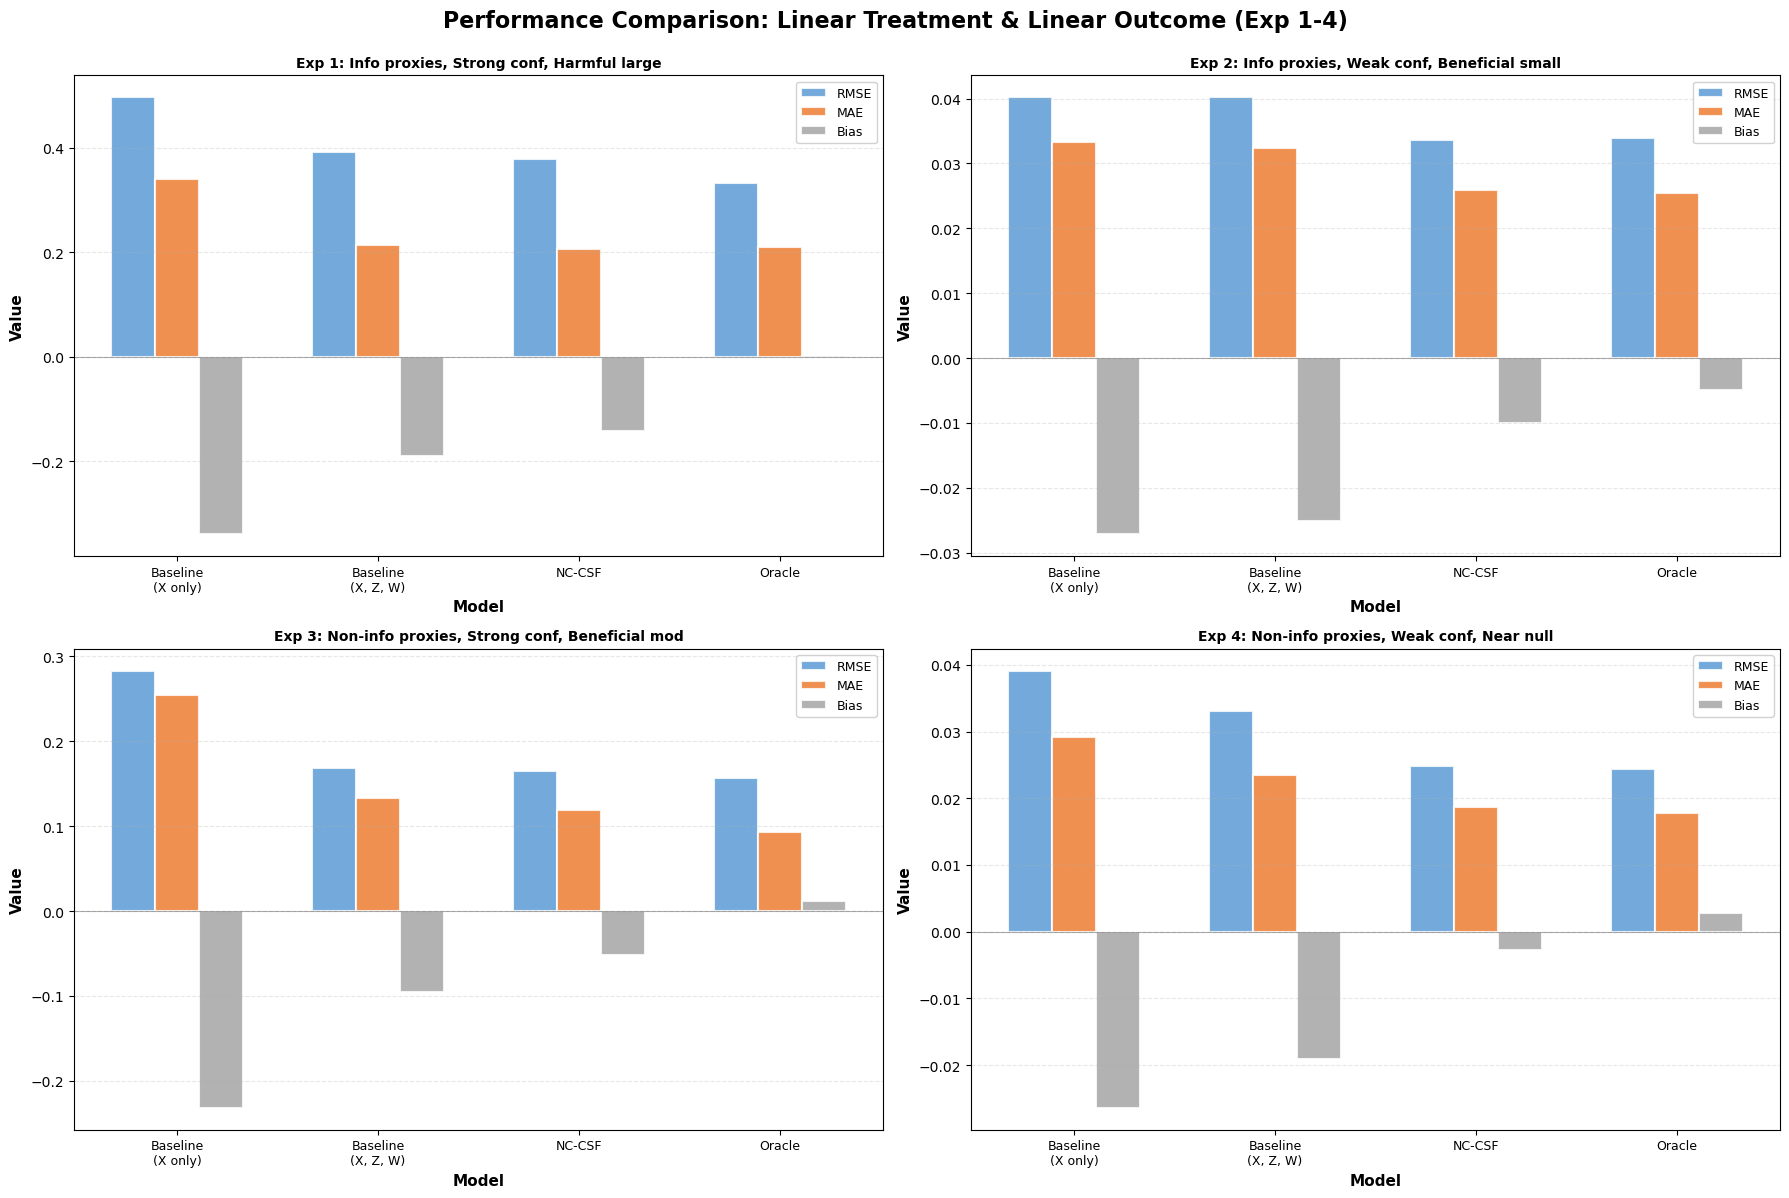

In [22]:
import matplotlib.pyplot as plt
import numpy as np

def plot_comparison(df, title, case_name):
    """Create grouped bar plot with models on x-axis and metrics as colored bars"""
    
    # Metrics to plot (excluding Pearson r due to scale differences)
    metrics = ['RMSE', 'MAE', 'Bias']
    models = ['Baseline with X only', 'Baseline with X, Z, W', 'NC-CSF', 'Oracle']
    
    # Colors for each metric (matching your screenshot style)
    metric_colors = {
        'RMSE': '#5B9BD5',      # Blue
        'MAE': '#ED7D31',       # Orange
        'Bias': '#A5A5A5'       # Gray
    }
    
    # Get unique experiments
    experiments = df['Experiment'].unique()
    n_experiments = len(experiments)
    
    # Create subplots - one for each experiment
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()
    
    for exp_idx, experiment in enumerate(experiments):
        ax = axes[exp_idx]
        exp_data = df[df['Experiment'] == experiment]
        
        x = np.arange(len(models))
        width = 0.22  # Width of bars (adjusted for 3 metrics)
        
        # Plot bars for each metric
        for metric_idx, metric in enumerate(metrics):
            offset = (metric_idx - 1) * width
            values = [exp_data[exp_data['Model'] == model][metric].values[0] for model in models]
            ax.bar(x + offset, values, width, label=metric, color=metric_colors[metric], 
                   alpha=0.85, edgecolor='white', linewidth=1.5)
        
        # Customize subplot
        ax.set_xlabel('Model', fontsize=11, fontweight='bold')
        ax.set_ylabel('Value', fontsize=11, fontweight='bold')
        ax.set_title(f'{experiment}', fontsize=10, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(['Baseline\n(X only)', 'Baseline\n(X, Z, W)', 'NC-CSF', 'Oracle'], 
                          fontsize=9, ha='center')
        ax.legend(loc='best', fontsize=9, framealpha=0.9)
        ax.grid(True, alpha=0.3, linestyle='--', axis='y')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.3)
    
    fig.suptitle(title, fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()

# Create plots for each case
print("Creating plot 1: Linear Treatment & Linear Outcome")
plot_comparison(df_linear_linear, 'Performance Comparison: Linear Treatment & Linear Outcome (Exp 1-4)', 
                'Linear-Linear')

Creating plot 2: Linear Treatment & Non-linear Outcome


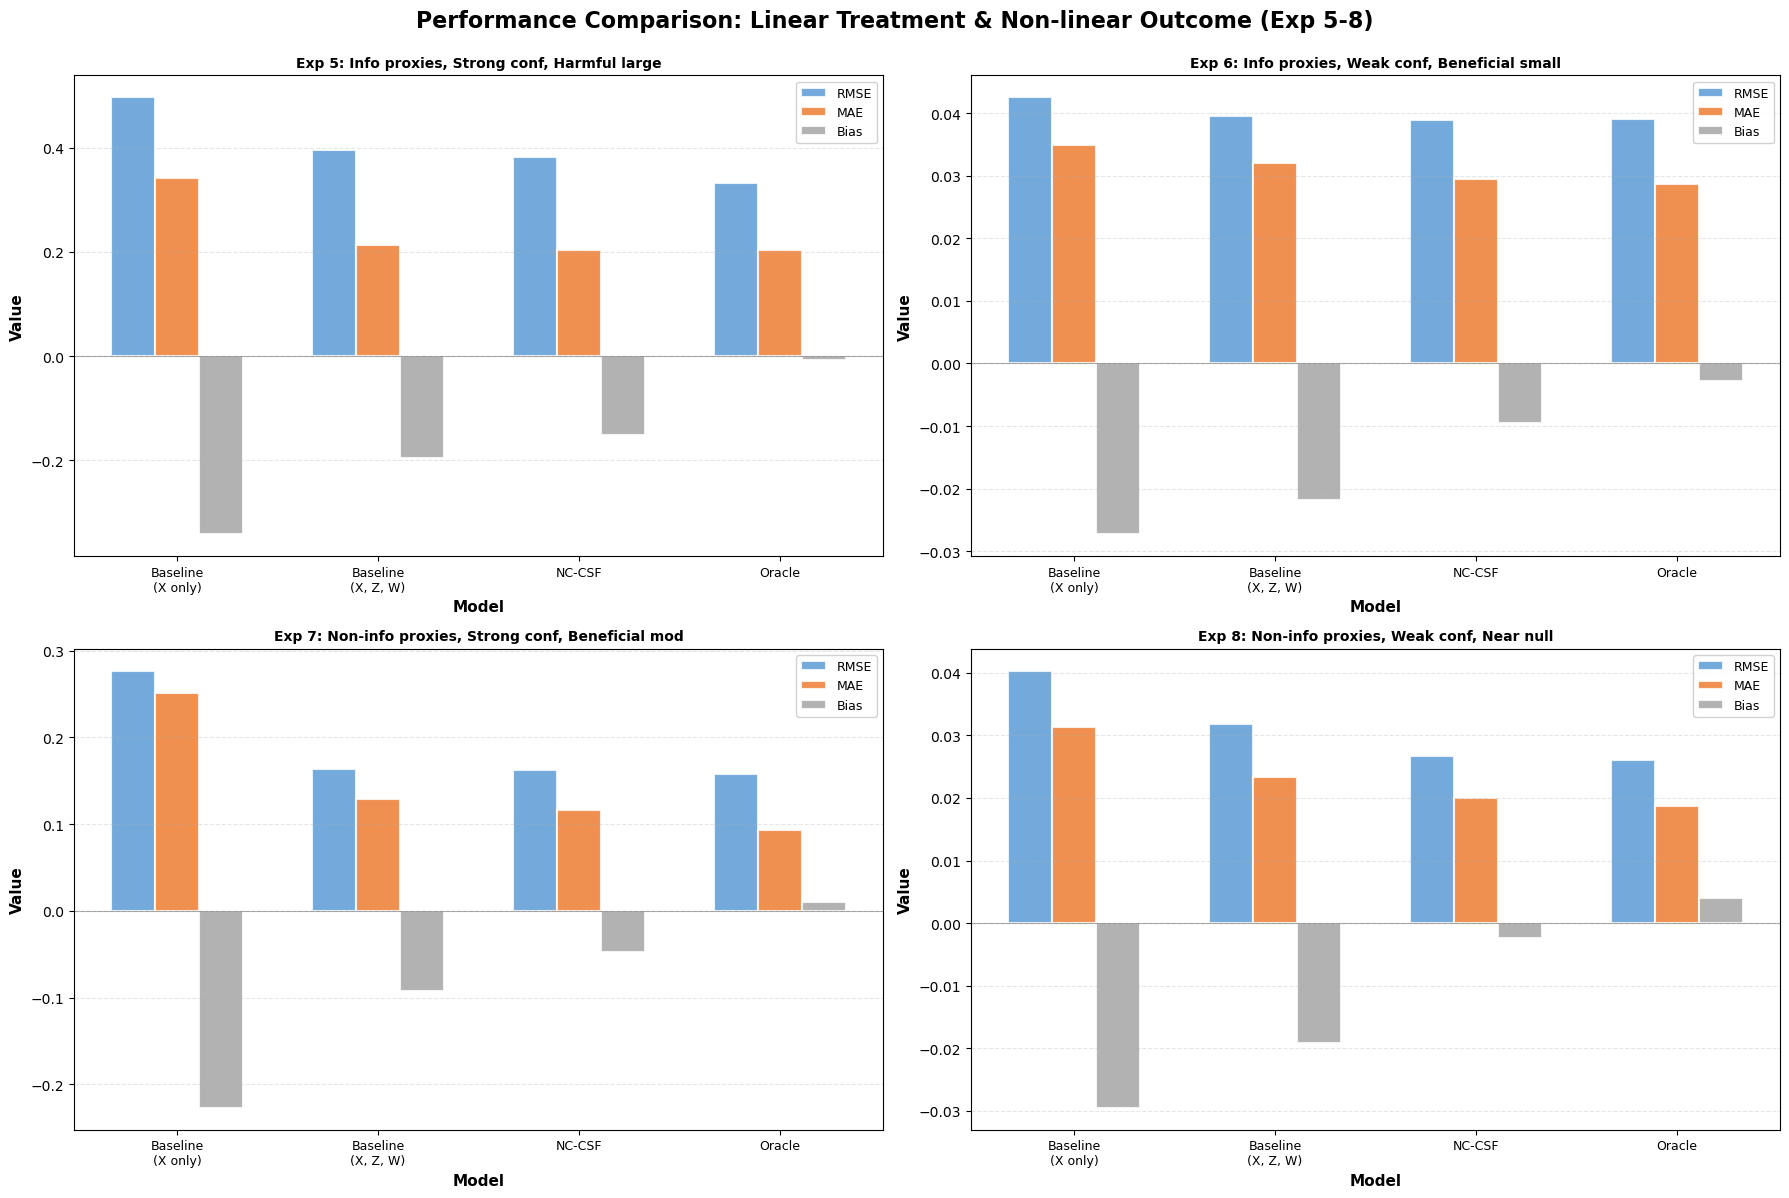

In [23]:
print("Creating plot 2: Linear Treatment & Non-linear Outcome")
plot_comparison(df_linear_nonlinear, 'Performance Comparison: Linear Treatment & Non-linear Outcome (Exp 5-8)', 
                'Linear-Nonlinear')

Creating plot 3: Non-linear Treatment & Non-linear Outcome


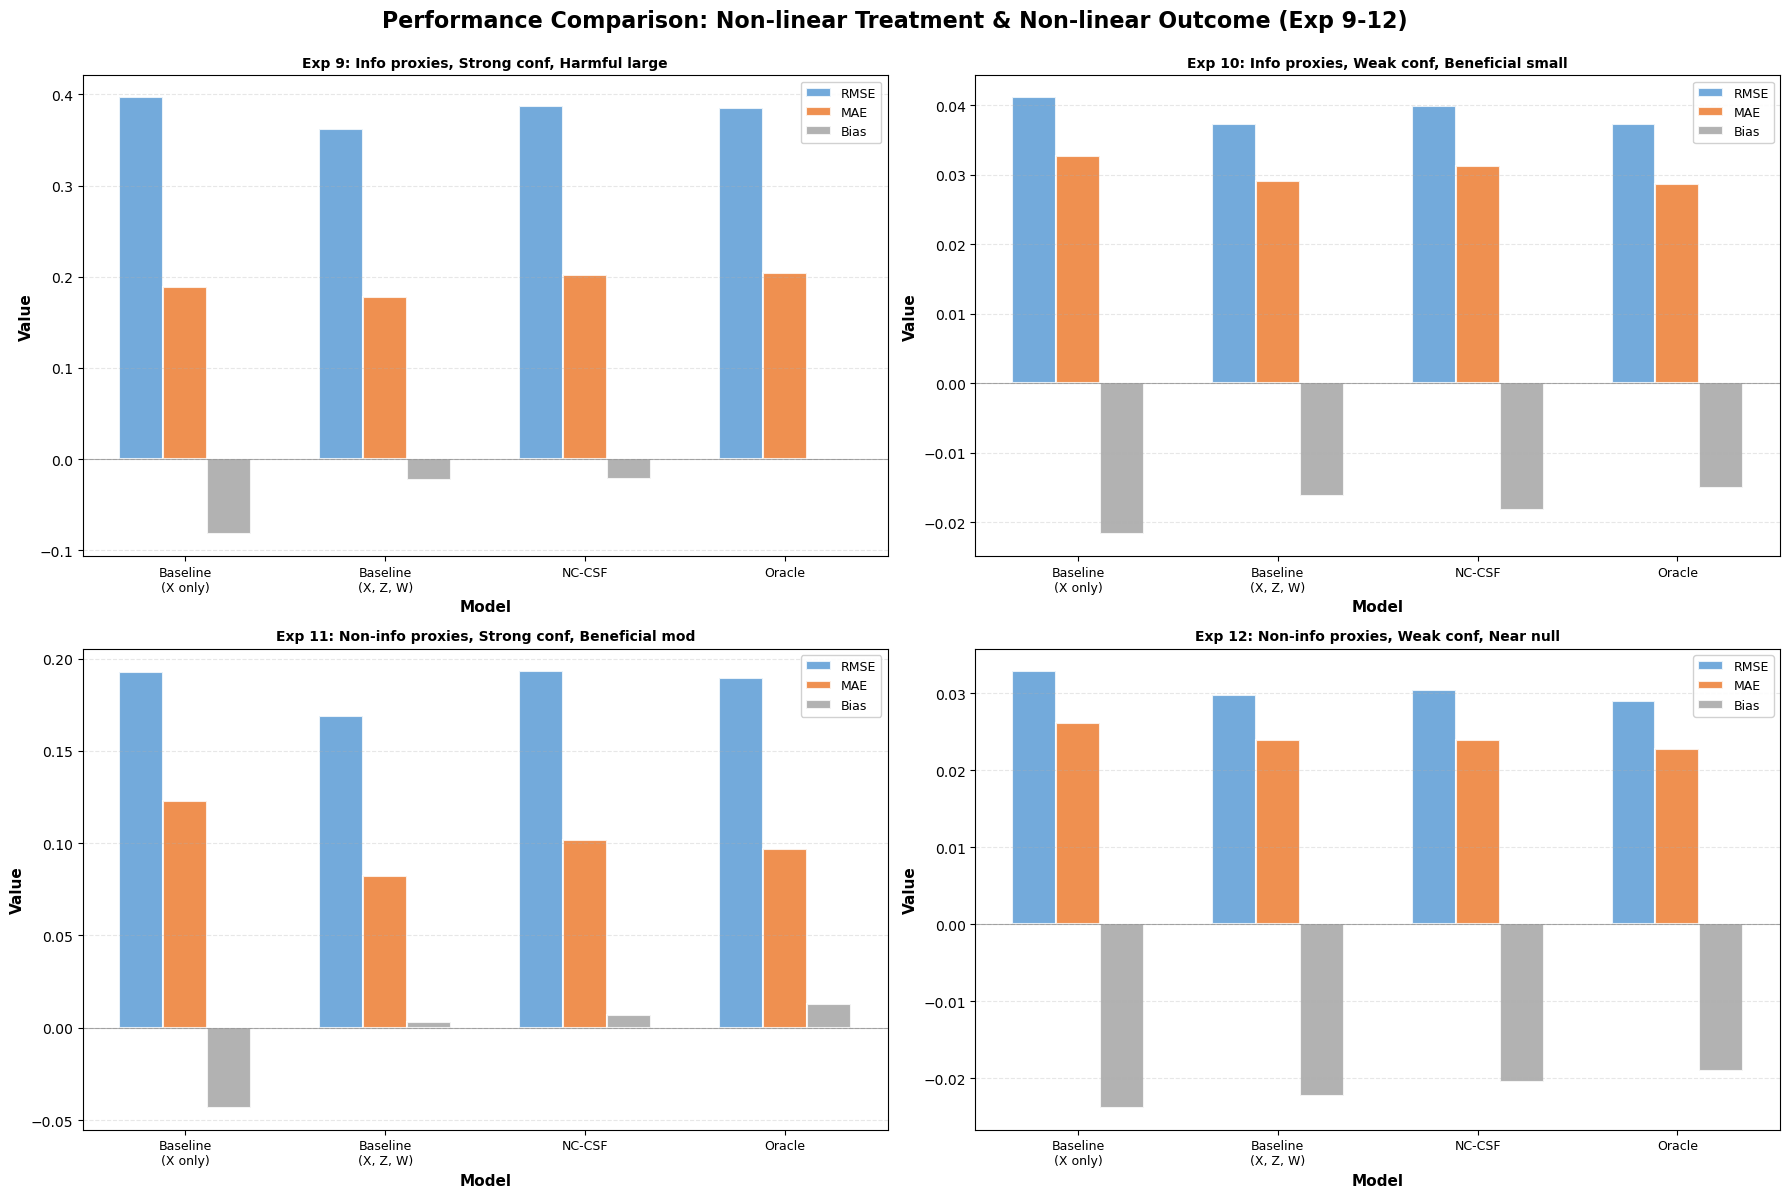

In [24]:
print("Creating plot 3: Non-linear Treatment & Non-linear Outcome")
plot_comparison(df_nonlinear_nonlinear, 'Performance Comparison: Non-linear Treatment & Non-linear Outcome (Exp 9-12)', 
                'Nonlinear-Nonlinear')